In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [4]:
def normalizar(img, size=40):
    ys, xs = np.where(img > 0)
    if len(xs) == 0:
        return np.zeros((size, size), dtype=np.uint8)

    recorte = img[ys.min():ys.max()+1, xs.min():xs.max()+1]

    h, w = recorte.shape
    escala = (size - 8) / max(h, w)
    recorte = cv2.resize(
        recorte,
        (int(w * escala), int(h * escala)),
        interpolation=cv2.INTER_AREA
    )

    canvas = np.zeros((size, size), dtype=np.uint8)
    y0 = (size - recorte.shape[0]) // 2
    x0 = (size - recorte.shape[1]) // 2
    canvas[y0:y0+recorte.shape[0], x0:x0+recorte.shape[1]] = recorte

    return canvas


In [166]:
def segmentar_letras(ruta_imagen):
    # 1. Leer imagen en color (aunque sea blanco y negro)
    img_color = cv2.imread(ruta_imagen)

    # 2. Convertir a escala de grises
    img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # 3. Mejorar contraste
    img = cv2.equalizeHist(img)

    # 4. Suavizar ruido
    img = cv2.GaussianBlur(img, (5, 5), 0)

    # 5. Binarización automática
    _, binaria = cv2.threshold(
        img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # --- SOLO PARA MANUSCRITO: unir trazos ---
    kernel = np.ones((3, 3), np.uint8)
    binaria = cv2.morphologyEx(binaria, cv2.MORPH_CLOSE, kernel)

    # 6. Buscar contornos
    contornos, _ = cv2.findContours(
        binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    letras = []
    for c in contornos:
        x, y, w, h = cv2.boundingRect(c)

        # 7. Filtrar ruido pequeño
        if w * h < 40:
            continue

        letra = binaria[y:y+h, x:x+w]
        letra = normalizar(letra)
        letras.append((x, letra))

    # 8. Ordenar de izquierda a derecha
    letras.sort(key=lambda x: x[0])
    return letras



In [6]:
def cargar_plantillas(ruta):
    plantillas = {}
    for letra in os.listdir(ruta):
        carpeta = os.path.join(ruta, letra)
        if not os.path.isdir(carpeta):
            continue

        plantillas[letra] = []
        for f in os.listdir(carpeta):
            img = cv2.imread(os.path.join(carpeta, f), cv2.IMREAD_GRAYSCALE)
            _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            img = normalizar(img)
            plantillas[letra].append(img)

    return plantillas


In [8]:
plantillas_minus = cargar_plantillas("data/train/impresos/minusculas")
plantillas_mayus = cargar_plantillas("data/train/impresos/mayusculas")
plantillas_nums  = cargar_plantillas("data/train/impresos/numeros")


In [9]:
def reconocer_letra_con_confianza(letra, plantillas):
    resultados = []

    for etiqueta, lista in plantillas.items():
        scores = []
        for plantilla in lista:
            score = cv2.matchTemplate(
                letra, plantilla, cv2.TM_CCOEFF_NORMED
            )[0][0]
            scores.append(score)

        resultados.append((etiqueta, float(np.mean(scores))))

    resultados.sort(key=lambda x: x[1], reverse=True)

    mejor_letra, mejor_score = resultados[0]
    segunda_score = resultados[1][1] if len(resultados) > 1 else 0

    confianza = max(0.0, min(1.0, (mejor_score - segunda_score) * 5)) * 100

    return mejor_letra, confianza


In [127]:
def ocr_imagen(ruta_imagen):
    # 1. Segmentamos la imagen en caracteres
    letras = segmentar_letras(ruta_imagen)
    letras = unir_puntos_i(letras)

    texto = ""
    confianzas = []

    # --- calcular distancia media entre letras ---
    xs = [x for x, _ in letras]
    if len(xs) > 1:
        distancias = [xs[i+1] - xs[i] for i in range(len(xs)-1)]
        distancia_media = sum(distancias) / len(distancias)
    else:
        distancia_media = 0

    # 2. Procesamos cada carácter
    for i, (x, letra) in enumerate(letras):
        # Normalizamos siempre
        letra = normalizar(letra)

        # Reconocimiento total: minúsculas, mayúsculas y números
        c, conf = reconocer_letra_total(letra)

        # Si la confianza es muy baja, no inventamos
        if conf < 25:
            c = "?"

        # Corrección específica l / i / I
        if c in ["l", "i", "I"]:
            c = corregir_liI(letra, c)

        texto += c
        confianzas.append(conf)

        # --- detección de espacios ---
        if i < len(letras) - 1:
            gap = letras[i+1][0] - x

            ys, xs = np.where(letra > 0)
            ancho_letra = xs.max() - xs.min() + 1 if len(xs) > 0 else 0

            if gap > ancho_letra * 2.4 and gap > distancia_media * 1.7:
                texto += " "

    # 3. Confianza global (media)
    if len(confianzas) > 0:
        confianza_global = sum(confianzas) / len(confianzas)
    else:
        confianza_global = 0

    # Penalizar si hay muchas dudas
    num_dudas = texto.count("?")
    if len(texto) > 0:
        confianza_global *= (1 - num_dudas / len(texto))

    return texto, confianza_global




In [88]:
def es_muy_fina(img):
    return proporcion(img) < 0.25


In [89]:
def reconocer_letra_total(letra_img):
    c_min, conf_min = reconocer_letra_con_confianza(letra_img, plantillas_minus)
    c_may, conf_may = reconocer_letra_con_confianza(letra_img, plantillas_mayus)

    if es_muy_fina(letra_img):
     c_num, conf_num = "", -1  # descartamos números
    else:
     c_num, conf_num = reconocer_letra_con_confianza(letra_img, plantillas_nums)


    # Elegimos el de mayor confianza
    if conf_may >= conf_min and conf_may >= conf_num:
        return c_may, conf_may
    elif conf_min >= conf_num:
        return c_min, conf_min
    else:
        return c_num, conf_num


In [64]:
def proporcion(img):
    ys, xs = np.where(img > 0)
    if len(xs) == 0:
        return 0
    w = xs.max() - xs.min() + 1
    h = ys.max() - ys.min() + 1
    return w / h


In [56]:
def tiene_punto(img):
    h = img.shape[0]
    parte_superior = img[:h//3, :]
    return np.sum(parte_superior > 0) > 15


In [73]:
def unir_puntos_i(letras):
    resultado = []
    usados = set()

    for i, (x1, img1) in enumerate(letras):
        if i in usados:
            continue

        for j, (x2, img2) in enumerate(letras):
            if i == j or j in usados:
                continue

            # si uno es muy pequeño y está encima del otro
            if img2.shape[0] < img1.shape[0] * 0.4 and abs(x1 - x2) < 10:
                nueva = np.maximum(img1, img2)
                resultado.append((x1, nueva))
                usados.add(i)
                usados.add(j)
                break
        else:
            resultado.append((x1, img1))
            usados.add(i)

    resultado.sort(key=lambda x: x[0])
    return resultado


In [57]:
def altura_relativa(img):
    ys, _ = np.where(img > 0)
    if len(ys) == 0:
        return 0
    return ys.max() - ys.min()


In [70]:
def corregir_liI(img, c):
    prop = proporcion(img)
    altura = altura_relativa(img)

    # i: tiene punto y es fina
    if tiene_punto(img):
        return "i"

    # l: muy fina y no muy alta
    if prop < 0.25 and altura < 32:
        return "l"

    # I: fina pero muy alta
    if prop < 0.25 and altura >= 32:
        return "I"

    return c


In [133]:
texto, confianza = ocr_imagen("data/test/prueba3.png")

print("Texto reconocido:", texto)
print(f"Confianza: {confianza:.2f}%")


Texto reconocido: ABCD123
Confianza: 92.98%


In [134]:
texto, confianza = ocr_imagen("data/test/prueba1.png")

print("Texto reconocido:", texto)
print(f"Confianza: {confianza:.2f}%")


Texto reconocido: Aa1
Confianza: 100.00%


In [149]:
texto, confianza = ocr_imagen("data/test/prueba2.png")

print("Texto reconocido:", texto)
print(f"Confianza: {confianza:.2f}%")


Texto reconocido: sH0
Confianza: 94.60%


In [136]:
texto, confianza = ocr_imagen("data/test/prueba4.png")

print("Texto reconocido:", texto)
print(f"Confianza: {confianza:.2f}%")


Texto reconocido: s5s
Confianza: 100.00%


In [173]:
texto, confianza = ocr_imagen("data/test/prueba5.png")

print("Texto reconocido:", texto)
print(f"Confianza: {confianza:.2f}%")


Texto reconocido: Lola
Confianza: 82.74%


In [138]:
texto, confianza = ocr_imagen("data/test/prueba6.png")

print("Texto reconocido:", texto)
print(f"Confianza: {confianza:.2f}%")


Texto reconocido: Aa
Confianza: 100.00%


In [139]:
texto, confianza = ocr_imagen("data/test/prueba7.png") #Soy lydia

print("Texto reconocido:", texto)
print(f"Confianza: {confianza:.2f}%")


Texto reconocido: soY lYdl?a
Confianza: 73.77%


In [140]:
texto, confianza = ocr_imagen("data/test/prueba8.png") #inteligente

print("Texto reconocido:", texto)
print(f"Confianza: {confianza:.2f}%")

Texto reconocido: lntell?gente
Confianza: 73.18%


In [141]:
texto, confianza = ocr_imagen("data/test/prueba9.png") #instituto

print("Texto reconocido:", texto)
print(f"Confianza: {confianza:.2f}%")

Texto reconocido: l?n stl?tu to
Confianza: 64.39%


In [148]:
texto, confianza = ocr_imagen("data/test/prueba10.png") #Aa 7ht

print("Texto reconocido:", texto)
print(f"Confianza: {confianza:.2f}%")

Texto reconocido: Aa 7Lt
Confianza: 90.51%


In [146]:
texto, confianza = ocr_imagen("data/test/prueba11.png") #BIG TEXT

print("Texto reconocido:", texto)
print(f"Confianza: {confianza:.2f}%")

Texto reconocido: m
Confianza: 81.78%


In [151]:
plantillas_manus_minus = cargar_plantillas("data/train/manuscritos/minusculas")
plantillas_manus_mayus = cargar_plantillas("data/train/manuscritos/mayusculas")
plantillas_manus_nums  = cargar_plantillas("data/train/manuscritos/numeros")


In [152]:
print(len(plantillas_manus_minus), "letras manuscritas minúsculas")
print(len(plantillas_manus_mayus), "letras manuscritas mayúsculas")
print(len(plantillas_manus_nums), "números manuscritos")


27 letras manuscritas minúsculas
27 letras manuscritas mayúsculas
10 números manuscritos


(np.float64(-0.5), np.float64(39.5), np.float64(39.5), np.float64(-0.5))

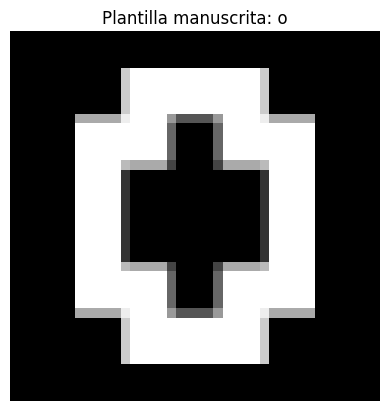

In [155]:
ejemplo = list(plantillas_manus_minus.keys())[0]
plt.imshow(plantillas_manus_minus[ejemplo][0], cmap="gray")
plt.title(f"Plantilla manuscrita: {ejemplo}")
plt.axis("off")


In [159]:
letras = segmentar_letras("data/test/manus_a.png")

for _, letra in letras:
    c, conf = reconocer_letra_con_confianza(letra, plantillas_manus_minus)
    print(f"Reconocido: {c}  Confianza: {conf:.2f}%")



Reconocido: a  Confianza: 28.49%


In [160]:
letras = segmentar_letras("data/test/manus_m.png")

for _, letra in letras:
    c, conf = reconocer_letra_con_confianza(letra, plantillas_manus_minus)
    print(f"Reconocido: {c}  Confianza: {conf:.2f}%")



Reconocido: m  Confianza: 33.80%


In [161]:
letras = segmentar_letras("data/test/manus_manuscrita.png")

for _, letra in letras:
    c, conf = reconocer_letra_con_confianza(letra, plantillas_manus_minus)
    print(f"Reconocido: {c}  Confianza: {conf:.2f}%")



Reconocido: m  Confianza: 14.99%


In [167]:
letras = segmentar_letras("data/test/manus_sol.png")

for _, letra in letras:
    c, conf = reconocer_letra_con_confianza(letra, plantillas_manus_minus)
    print(f"Reconocido: {c}  Confianza: {conf:.2f}%")



Reconocido: a  Confianza: 4.51%
Reconocido: v  Confianza: 8.67%
Reconocido: m  Confianza: 8.67%
Reconocido: m  Confianza: 46.03%
Reconocido: w  Confianza: 8.97%
Reconocido: m  Confianza: 22.70%
Reconocido: m  Confianza: 13.46%
Reconocido: m  Confianza: 17.78%
Reconocido: m  Confianza: 4.22%
Reconocido: w  Confianza: 0.36%
Reconocido: w  Confianza: 6.66%
Reconocido: m  Confianza: 3.46%
Reconocido: v  Confianza: 2.02%
Reconocido: m  Confianza: 19.36%
Reconocido: m  Confianza: 21.31%
Reconocido: x  Confianza: 1.55%
Reconocido: a  Confianza: 10.79%
Reconocido: h  Confianza: 5.72%
Reconocido: h  Confianza: 1.96%
Reconocido: v  Confianza: 11.63%
Reconocido: m  Confianza: 5.16%
Reconocido: x  Confianza: 2.27%
Reconocido: m  Confianza: 1.13%
Reconocido: v  Confianza: 5.77%
Reconocido: w  Confianza: 5.17%
Reconocido: w  Confianza: 40.17%
Reconocido: x  Confianza: 1.08%
Reconocido: w  Confianza: 24.51%
Reconocido: w  Confianza: 5.72%
Reconocido: w  Confianza: 20.47%
Reconocido: w  Confianza: 10.

In [168]:
letras = segmentar_letras("data/test/manus_sol1.png")

for _, letra in letras:
    c, conf = reconocer_letra_con_confianza(letra, plantillas_manus_minus)
    print(f"Reconocido: {c}  Confianza: {conf:.2f}%")

Reconocido: w  Confianza: 15.87%
Reconocido: m  Confianza: 27.17%
Reconocido: m  Confianza: 18.56%
Reconocido: m  Confianza: 22.97%
Reconocido: w  Confianza: 15.43%
Reconocido: m  Confianza: 14.60%
Reconocido: w  Confianza: 16.35%
Reconocido: h  Confianza: 15.54%
Reconocido: m  Confianza: 8.17%
Reconocido: x  Confianza: 0.05%
Reconocido: m  Confianza: 4.48%
Reconocido: q  Confianza: 0.29%
Reconocido: m  Confianza: 35.98%
Reconocido: m  Confianza: 6.24%
Reconocido: m  Confianza: 28.26%
Reconocido: a  Confianza: 6.16%
Reconocido: m  Confianza: 42.74%
Reconocido: w  Confianza: 25.12%
Reconocido: f  Confianza: 2.14%
Reconocido: c  Confianza: 2.57%
Reconocido: x  Confianza: 20.74%
Reconocido: m  Confianza: 6.98%
Reconocido: w  Confianza: 15.18%
Reconocido: w  Confianza: 2.10%
Reconocido: w  Confianza: 62.76%
Reconocido: w  Confianza: 26.66%
Reconocido: a  Confianza: 13.29%


In [169]:
letras = segmentar_letras("data/test/manus_q.png")

for _, letra in letras:
    c, conf = reconocer_letra_con_confianza(letra, plantillas_manus_minus)
    print(f"Reconocido: {c}  Confianza: {conf:.2f}%")

Reconocido: q  Confianza: 14.22%


In [170]:
letras = segmentar_letras("data/test/manus_sol2.png")

for _, letra in letras:
    c, conf = reconocer_letra_con_confianza(letra, plantillas_manus_minus)
    print(f"Reconocido: {c}  Confianza: {conf:.2f}%")

Reconocido: w  Confianza: 29.85%
Reconocido: m  Confianza: 28.16%
Reconocido: e  Confianza: 0.64%


In [171]:
letras = segmentar_letras("data/test/manus_bol.png")

for _, letra in letras:
    c, conf = reconocer_letra_con_confianza(letra, plantillas_manus_minus)
    print(f"Reconocido: {c}  Confianza: {conf:.2f}%")

Reconocido: b  Confianza: 2.29%
Reconocido: m  Confianza: 1.88%
Reconocido: w  Confianza: 0.86%
Reconocido: w  Confianza: 17.20%


In [172]:
letras = segmentar_letras("data/test/manus_orden.png")

for _, letra in letras:
    c, conf = reconocer_letra_con_confianza(letra, plantillas_manus_minus)
    print(f"Reconocido: {c}  Confianza: {conf:.2f}%")

Reconocido: w  Confianza: 25.76%
Reconocido: l  Confianza: 14.21%
Reconocido: e  Confianza: 2.18%
Reconocido: e  Confianza: 10.69%
